# **3D LiDAR Object Detection**

# **Setup**

In [ ]:
import os
import time 
import numpy as np

from scipy.spatial import KDTree 
# !pip install pyvista --quiet
# !pip install trame --quiet
# !pip install vtk --quiet
import pyvista as pv
from pyvista import examples
pv.set_plot_theme('document')

# Ignore Warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

The pyvista module is not an IPython extension.


In [35]:
# Get list of available jupyter extensions
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %code_wrap  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %mamba  %matplotlib  %micromamba  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%code_wrap  %%debug  %%file  %%html  %%javascript  %%js  %%l

# **Built In Example**

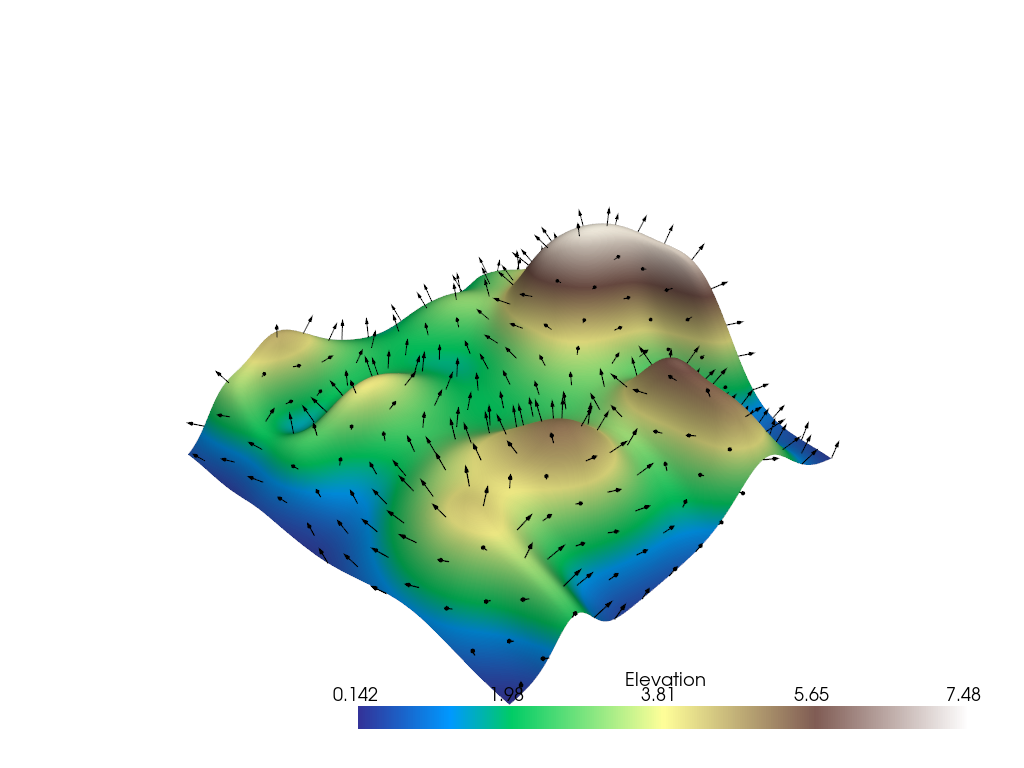

In [33]:
mesh = examples.load_random_hills()
arrows = mesh.glyph(scale='Normals', orient="Normals", tolerance=0.05)

p = pv.Plotter()
p.add_mesh(arrows,color='black')
p.add_mesh(mesh, scalars='Elevation', color='white',cmap='terrain', smooth_shading=True)
p.show()

# **Read Data File** 

In [21]:
# Load Point Cloud
pcd = pv.read('Data/MLS_UTWENTE_super_sample.ply')
pcd

PolyData (0x1bed5e3ae00)
  N Cells:    500000
  N Points:   500000
  N Strips:   0
  X Bounds:   6.455e+02, 8.689e+02
  Y Bounds:   3.522e+01, 2.142e+02
  Z Bounds:   3.240e+01, 5.908e+01
  N Arrays:   1

## **Points Data**

In [22]:
# Get Points Data
print(pcd.points.shape)
pcd.points 

(500000, 3)


pyvista_ndarray([[739.93, 206.51,  47.74],
                 [749.5 , 144.79,  35.25],
                 [743.63, 136.23,  35.24],
                 ...,
                 [767.65, 136.94,  43.3 ],
                 [780.22, 121.43,  46.18],
                 [752.51, 130.07,  35.25]], dtype=float32)

## **Elevation Data**

In [23]:
pcd_elevation = pcd.points[:, 2]
pcd_elevation.shape

(500000,)

# **Visualize Point Cloud**

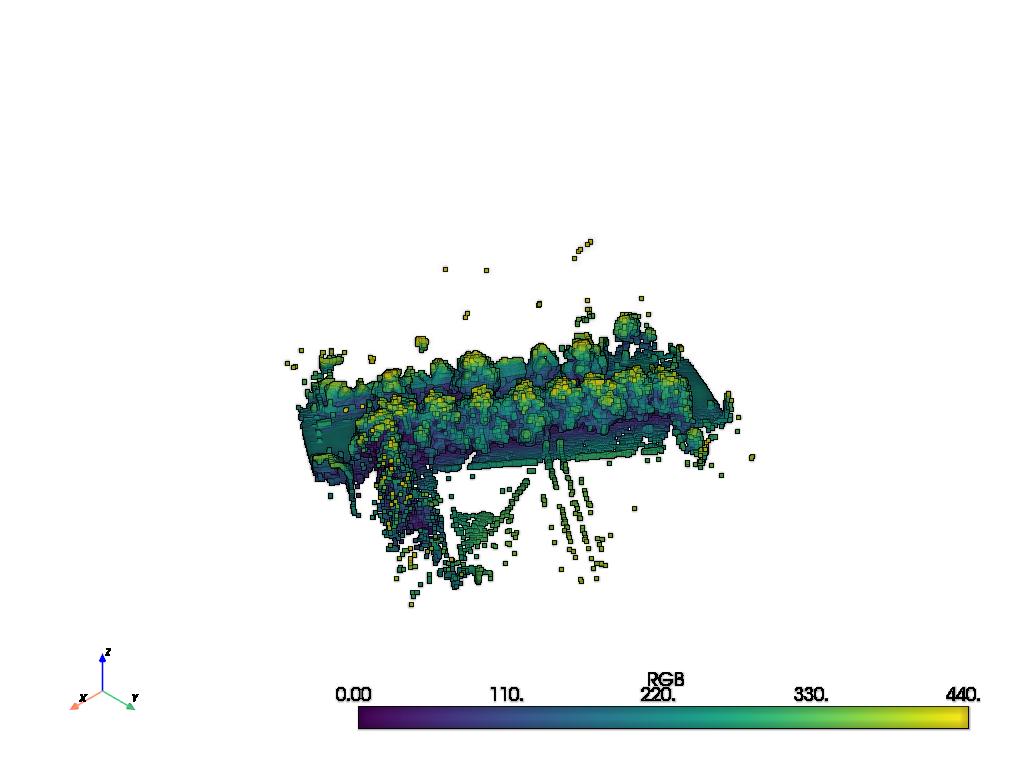

In [24]:
# Visualize Point Cloud
pcd_plot = pcd.plot(eye_dome_lighting=True)
pcd_plot

# **Reference**

- https://www.youtube.com/watch?v=F3IEobi7Li4
- https://github.com/maudzung/Complex-YOLOv4-Pytorch